# BayesianSimulatedData1

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tests.generate_dataset import generate_dataset_scheme1, generate_dataset_scheme2
from tests.train_test_split import train_test_split
from src.QDAClassifier import QDAClassifier
from src.NBClassifier import NBClassifier
from src.LDAClassifier import LDAClassifier

In [2]:
X, y = generate_dataset_scheme1(a=2)
X_train, X_test, y_train, y_test = train_test_split(X, y, 0.7)

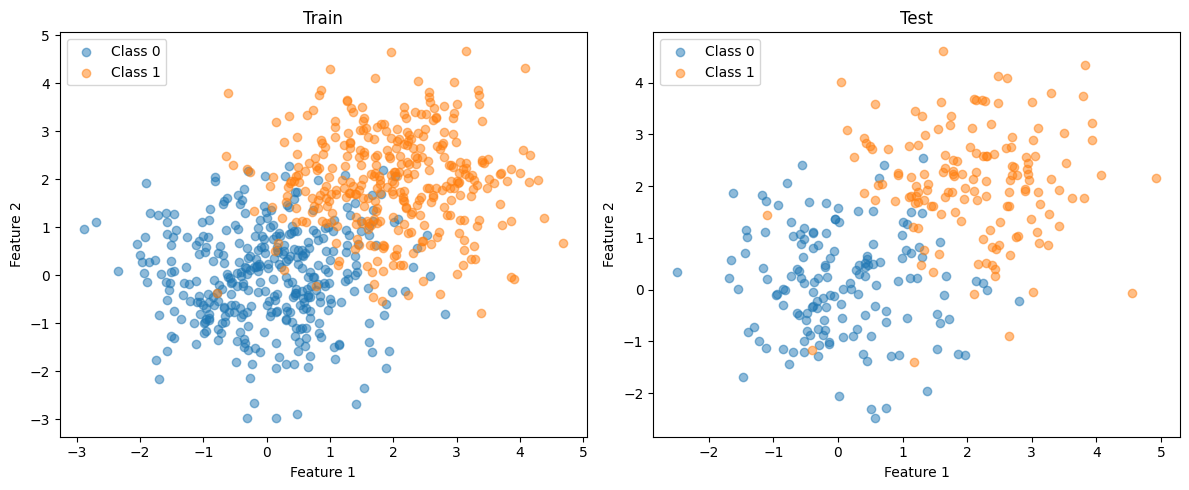

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, X_split, y_split, title in zip(axes, 
                                        [X_train, X_test], 
                                        [y_train, y_test], 
                                        ['Train', 'Test']):
    ax.scatter(X_split[y_split==0, 0], X_split[y_split==0, 1], label='Class 0', alpha=0.5)
    ax.scatter(X_split[y_split==1, 0], X_split[y_split==1, 1], label='Class 1', alpha=0.5)
    ax.set_title(title)
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    ax.legend()

plt.tight_layout()
plt.show()

In [4]:
X, y = generate_dataset_scheme2(a=2, correlation_coef=0.5)
X_train, X_test, y_train, y_test = train_test_split(X, y, 0.7)

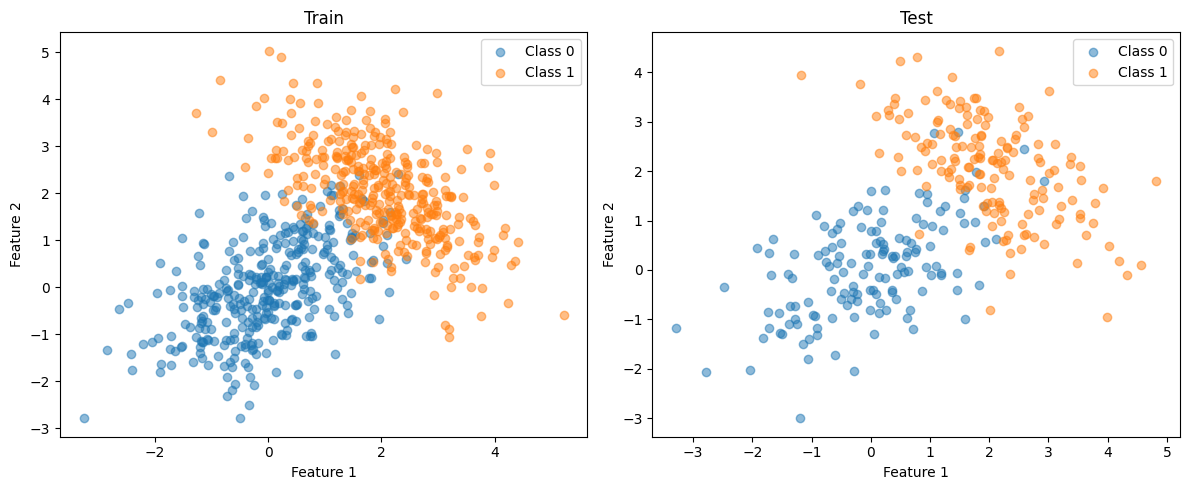

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, X_split, y_split, title in zip(axes, 
                                        [X_train, X_test], 
                                        [y_train, y_test], 
                                        ['Train', 'Test']):
    ax.scatter(X_split[y_split==0, 0], X_split[y_split==0, 1], label='Class 0', alpha=0.5)
    ax.scatter(X_split[y_split==1, 0], X_split[y_split==1, 1], label='Class 1', alpha=0.5)
    ax.set_title(title)
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    ax.legend()

plt.tight_layout()
plt.show()

### Perfomance with different mean values

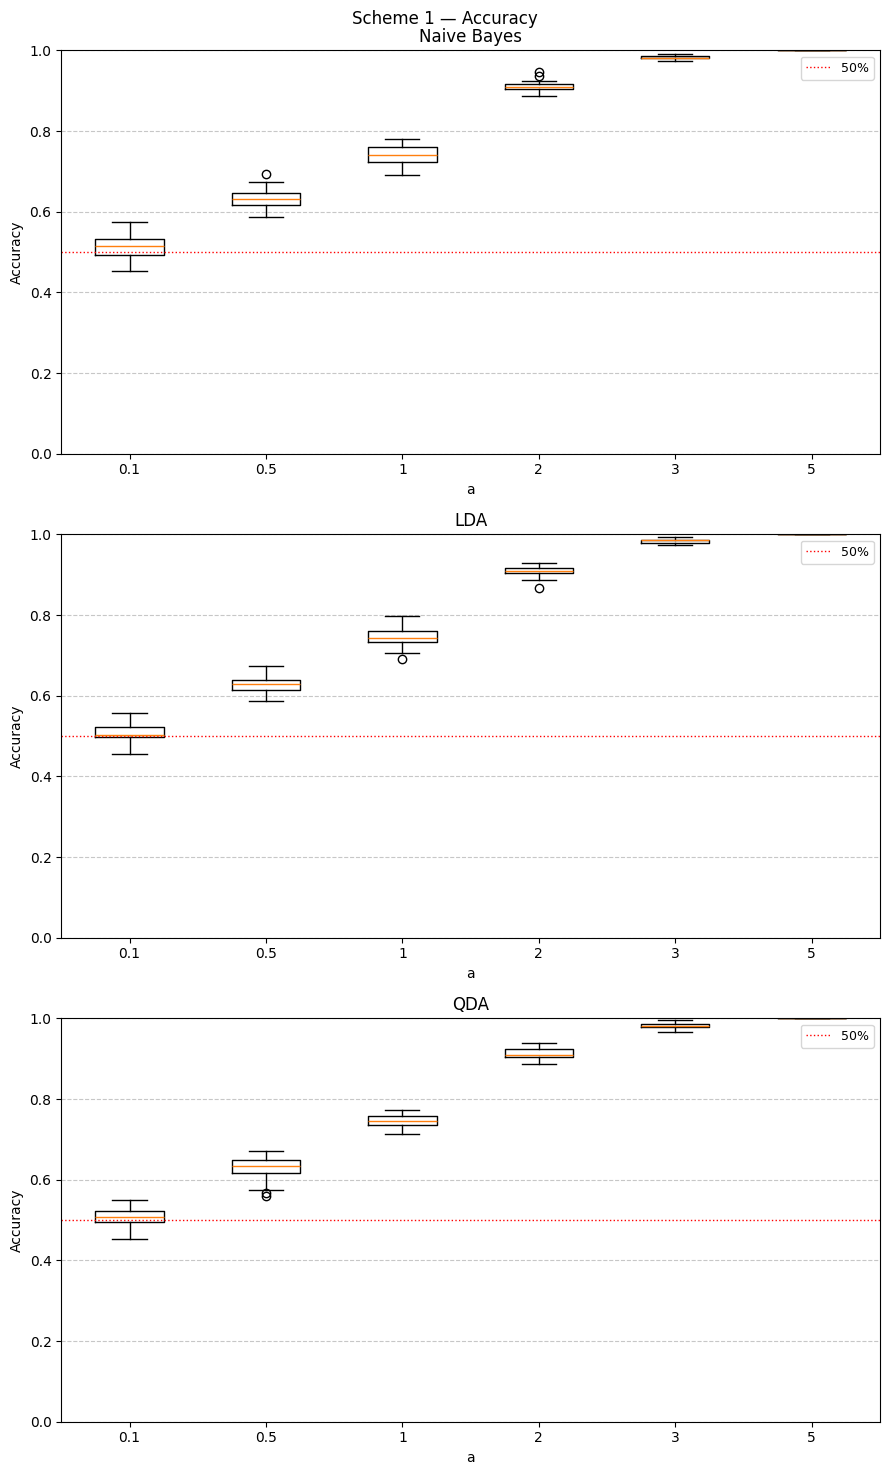

In [7]:
NB_accuracies = []
LDA_accuracies = []
QDA_accuracies = []

for i in [0.1,0.5,1,2,3,5]:
    X, y = generate_dataset_scheme1(a=i)
    accuracies = []
    for j in range(30):
        X_train, X_test, y_train, y_test = train_test_split(X, y, 0.7)
        classifier = NBClassifier()
        classifier.fit(X_train, y_train)
        y_pred = classifier.predict(X_test)
        accuracies.append(np.mean(y_pred == y_test))
    NB_accuracies.append(accuracies)
    accuracies = []
    for j in range(30):
        X_train, X_test, y_train, y_test = train_test_split(X, y, 0.7)
        classifier = LDAClassifier()
        classifier.fit(X_train, y_train)
        y_pred = classifier.predict(X_test)
        accuracies.append(np.mean(y_pred == y_test))
    LDA_accuracies.append(accuracies)
    accuracies = []
    for j in range(30):
        X_train, X_test, y_train, y_test = train_test_split(X, y, 0.7)
        classifier = QDAClassifier()
        classifier.fit(X_train, y_train)
        y_pred = classifier.predict(X_test)
        accuracies.append(np.mean(y_pred == y_test))
    QDA_accuracies.append(accuracies)

fig, axes = plt.subplots(3, 1, figsize=(9, 15))
for ax, accuracies, title in zip(axes,
                                  [NB_accuracies, LDA_accuracies, QDA_accuracies],
                                  ['Naive Bayes', 'LDA', 'QDA']):
    ax.boxplot(accuracies, tick_labels=[str(a) for a in [0.1,0.5,1,2,3,5]])
    ax.set_title(title)
    ax.set_xlabel('a')
    ax.set_ylabel('Accuracy')
    ax.set_ylim(0, 1)
    ax.yaxis.grid(True, linestyle='--', alpha=0.7)
    ax.set_axisbelow(True)
    
    ax.axhline(y=0.5, color='red', linestyle=':', linewidth=1, label='50%')
    ax.legend(fontsize=9)

plt.suptitle('Scheme 1 — Accuracy')
plt.tight_layout()
plt.show()


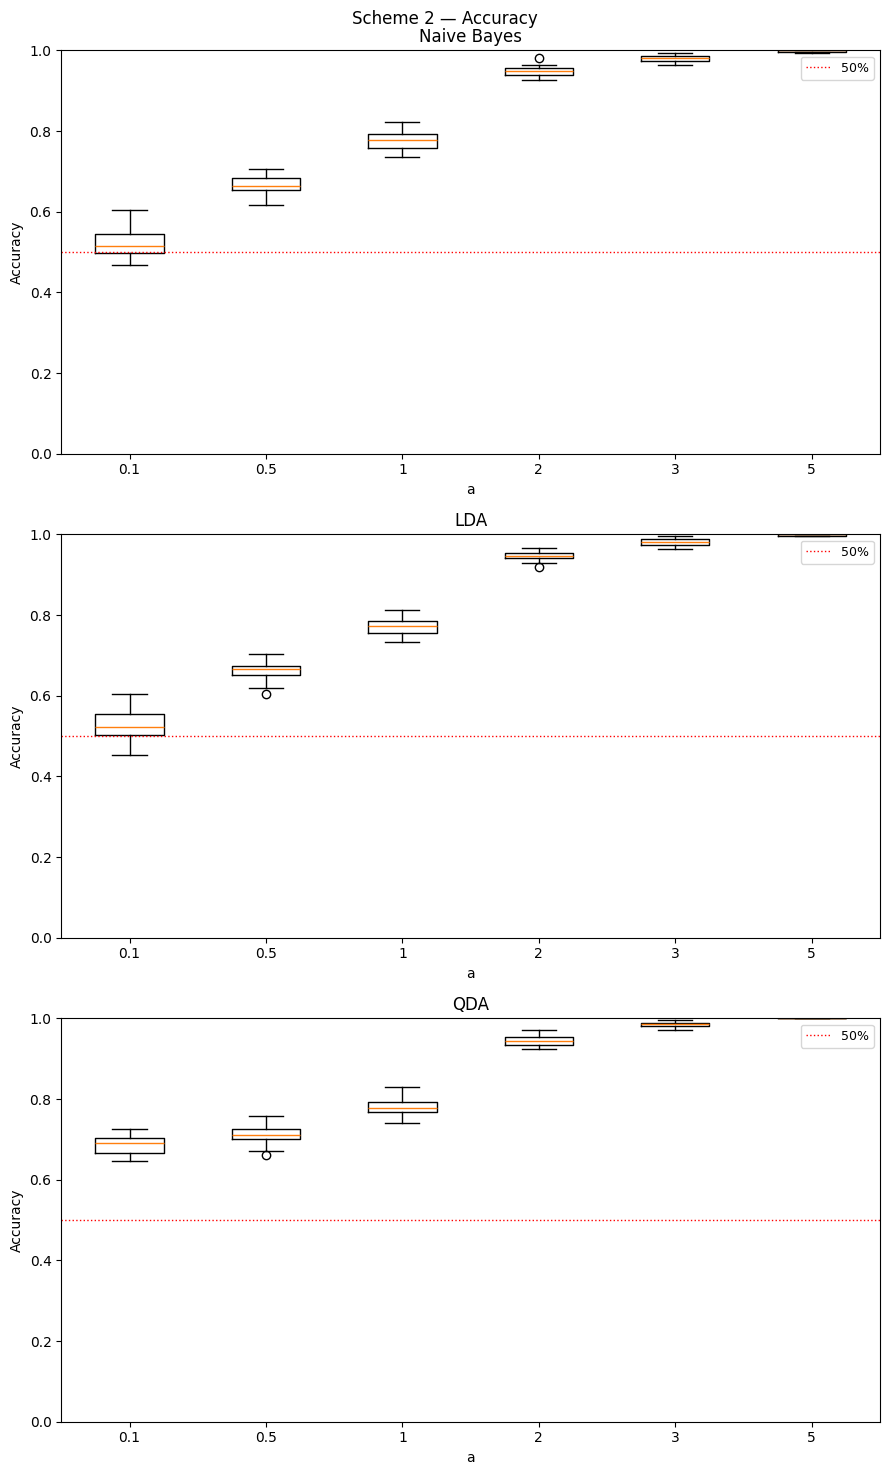

In [8]:
NB_accuracies = []
LDA_accuracies = []
QDA_accuracies = []

for i in [0.1,0.5,1,2,3,5]:
    X, y = generate_dataset_scheme2(a=i, correlation_coef=0.5)
    accuracies = []
    for j in range(30):
        X_train, X_test, y_train, y_test = train_test_split(X, y, 0.7)
        classifier = NBClassifier()
        classifier.fit(X_train, y_train)
        y_pred = classifier.predict(X_test)
        accuracies.append(np.mean(y_pred == y_test))
    NB_accuracies.append(accuracies)
    accuracies = []
    for j in range(30):
        X_train, X_test, y_train, y_test = train_test_split(X, y, 0.7)
        classifier = LDAClassifier()
        classifier.fit(X_train, y_train)
        y_pred = classifier.predict(X_test)
        accuracies.append(np.mean(y_pred == y_test))
    LDA_accuracies.append(accuracies)
    accuracies = []
    for j in range(30):
        X_train, X_test, y_train, y_test = train_test_split(X, y, 0.7)
        classifier = QDAClassifier()
        classifier.fit(X_train, y_train)
        y_pred = classifier.predict(X_test)
        accuracies.append(np.mean(y_pred == y_test))
    QDA_accuracies.append(accuracies)

fig, axes = plt.subplots(3, 1, figsize=(9, 15))
for ax, accuracies, title in zip(axes,
                                  [NB_accuracies, LDA_accuracies, QDA_accuracies],
                                  ['Naive Bayes', 'LDA', 'QDA']):
    ax.boxplot(accuracies, tick_labels=[str(a) for a in [0.1,0.5,1,2,3,5]])
    ax.set_title(title)
    ax.set_xlabel('a')
    ax.set_ylabel('Accuracy')
    ax.set_ylim(0, 1)
    ax.axhline(y=0.5, color='red', linestyle=':', linewidth=1, label='50%')
    ax.legend(fontsize=9)

plt.suptitle('Scheme 2 — Accuracy')
plt.tight_layout()
plt.show()
